<center>
    <font size="5"> Sieci neuronowe i uczenie głębokie<br/>
        <small><em>Studia stacjonarne II stopnia 2025/2026</em><br/>Kierunek: Matematyka stosowana<br>Specjalność: Analityka danych</small>
    </font>
</center>
<br>

# Laboratorium nr 12: Modele generatywne - generowanie syntetycznych obrazów

## Import bibliotek

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
import os
import time
from IPython import display

print("Numpy version:", np.__version__)
print("Tensorflow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

2026-04-27 21:49:31.065701: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Numpy version: 2.4.2
Tensorflow version: 2.20.0
Keras version: 3.13.2


## PixelCNN - Fashion MNIST

In [3]:
# num_classes = 10
input_shape = (28, 28, 1)

data = tf.keras.datasets.fashion_mnist.load_data()[0][0]
data = data.reshape(-1, 28, 28, 1)
# data = data/255.0

data = np.where(data < 30, 0, 1)
data = data.astype(np.uint8)
data.shape

(60000, 28, 28, 1)

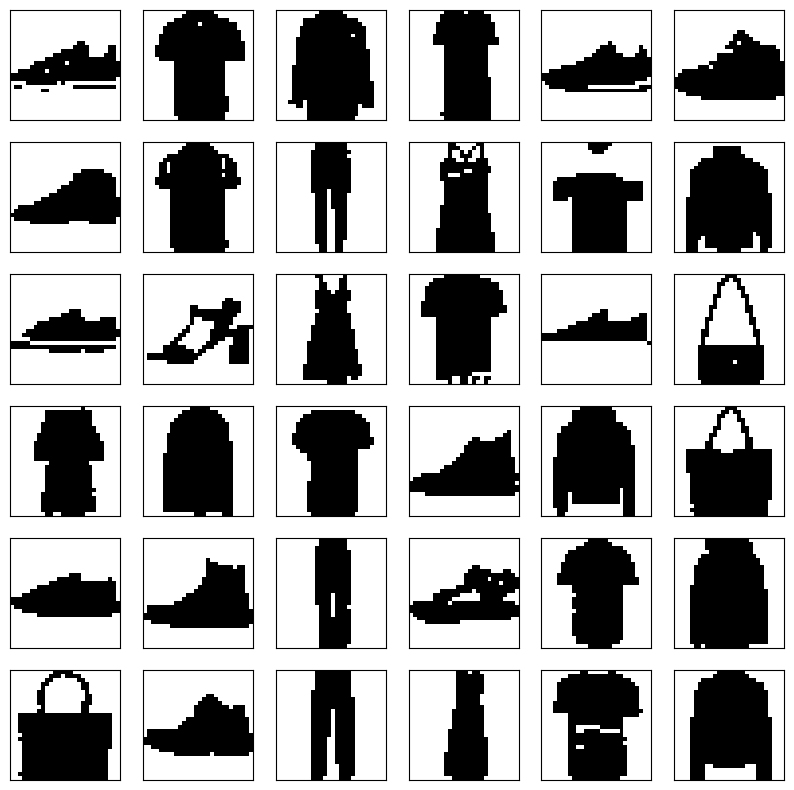

In [4]:
plt.figure(figsize=(10, 10))
random_inds = np.random.choice(60000, 36)
for i in range(36):
    plt.subplot(6, 6, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    image_ind = random_inds[i]
    plt.imshow(np.squeeze(data[image_ind]), cmap=plt.cm.binary)

### Warstwy modelu PixelCNN

In [5]:
class PixelConvLayer(layers.Layer):
    """
    Warstwa konwolucyjna z maskowaniem, kluczowa dla modeli autogresyjnych (PixelCNN).
    Gwarantuje, że przy przewidywaniu wartości danego piksela model 'widzi'
    tylko piksele wygenerowane przed nim (powyżej i po lewej).
    """

    def __init__(self, mask_type, **kwargs):
        super().__init__()
        self.mask_type = mask_type
        self.conv = layers.Conv2D(**kwargs)

    def build(self, input_shape):
        self.conv.build(input_shape)
        kernel_shape = self.conv.kernel.shape

        # 1. Inicjalizacja maski zerami
        self.mask = np.zeros(shape=kernel_shape)

        # 2. Zezwalamy na dostęp do pikseli w poprzednich wierszach obrazu
        self.mask[: kernel_shape[0] // 2, ...] = 1.0

        # 3. Zezwalamy na dostęp do pikseli w aktualnym wierszu, ale tylko po lewej stronie
        self.mask[kernel_shape[0] // 2, : kernel_shape[1] // 2, ...] = 1.0

        # 4. Maska 'B' (dla kolejnych warstw) pozwala dodatkowo na dostęp
        # do aktualnie przetwarzanego piksela z poprzednich warstw ukrytych.
        # Maska 'A' (dla pierwszej warstwy) izoluje piksel całkowicie.
        if self.mask_type == "B":
            self.mask[kernel_shape[0] // 2, kernel_shape[1] // 2, ...] = 1.0

    def call(self, inputs):
        # Nałożenie maski na wagi konwolucji przed wykonaniem operacji
        self.conv.kernel.assign(self.conv.kernel * self.mask)
        return self.conv(inputs)


class ResidualBlock(layers.Layer):
    def __init__(self, filters, **kwargs):
        super().__init__(**kwargs)
        self.conv1 = layers.Conv2D(filters=filters, kernel_size=1, activation="relu")
        self.pixel_conv = PixelConvLayer(
            mask_type="B",
            filters=filters // 2,
            kernel_size=3,
            activation="relu",
            padding="same",
        )
        self.conv2 = layers.Conv2D(filters=filters, kernel_size=1, activation="relu")

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.pixel_conv(x)
        x = self.conv2(x)
        return layers.add([inputs, x])

### Model

In [5]:
n_residual_blocks = 5
inputs = layers.Input(shape=input_shape)
x = PixelConvLayer(
    mask_type="A", filters=128, kernel_size=7, activation="relu", padding="same"
)(inputs)

for _ in range(n_residual_blocks):
    x = ResidualBlock(filters=128)(x)

for _ in range(2):
    x = PixelConvLayer(
        mask_type="B",
        filters=128,
        kernel_size=1,
        strides=1,
        activation="relu",
        padding="valid",
    )(x)

out = layers.Conv2D(
    filters=1, kernel_size=1, strides=1, activation="sigmoid", padding="valid"
)(x)
# out = keras.layers.Conv2D(filters=1, kernel_size=1, strides=1, activation="linear", padding="valid")(x)

pixel_cnn = tf.keras.Model(inputs, out)
adam = tf.keras.optimizers.Adam(learning_rate=0.0005)
# pixel_cnn.compile(optimizer=adam, loss="mse")
pixel_cnn.compile(optimizer=adam, loss="binary_crossentropy")

pixel_cnn.summary()

I0000 00:00:1777274610.380713  343562 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4078 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pixel_conv_layer                │ (None, 28, 28, 128)    │         6,400 │
│ (PixelConvLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block (ResidualBlock)  │ (None, 28, 28, 128)    │        98,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_1                │ (None, 28, 28, 128)    │        98,624 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_2                │ (None, 28, 28, 128)    │        98,624 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_3                │ (None, 28, 28, 128)    │        98,624 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_4                │ (None, 28, 28, 128)    │        98,624 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pixel_conv_layer_6              │ (None, 28, 28, 128)    │        16,512 │
│ (PixelConvLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pixel_conv_layer_7              │ (None, 28, 28, 128)    │        16,512 │
│ (PixelConvLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 1)      │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,673 (2.03 MB)

 Trainable params: 532,673 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
nepochs = 15  # zwiększyć
pixel_cnn.fit(
    x=data, y=data, batch_size=128, epochs=nepochs, validation_split=0.1, verbose=1
)

2026-04-27 09:23:39.145443: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 42336000 exceeds 10% of free system memory.
2026-04-27 09:23:39.663969: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 42336000 exceeds 10% of free system memory.
2026-04-27 09:23:39.926827: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 42336000 exceeds 10% of free system memory.
2026-04-27 09:23:40.138934: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 42336000 exceeds 10% of free system memory.


Epoch 1/15


2026-04-27 09:23:45.332996: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fde70002290 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-27 09:23:45.333041: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 Ti, Compute Capability 7.5
2026-04-27 09:23:45.634645: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-27 09:23:47.028440: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-04-27 09:23:50.074170: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[128,64,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[128,128,28,28]{3,2,1,0}, f32[64,128,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom

  1/422 ━━━━━━━━━━━━━━━━━━━━ 1:45:49 15s/step - loss: 0.6929

I0000 00:00:1777274635.260147  343970 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.2234

2026-04-27 09:24:34.600017: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[112,64,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[112,128,28,28]{3,2,1,0}, f32[64,128,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}


422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.2232

2026-04-27 09:24:39.741031: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[128,64,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[128,128,28,28]{3,2,1,0}, f32[64,128,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-04-27 09:24:42.132444: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[112,64,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[112,128,28,28]{3,2,1,0}, f32[64,128,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_tar

422/422 ━━━━━━━━━━━━━━━━━━━━ 63s 113ms/step - loss: 0.1452 - val_loss: 0.1115
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - loss: 0.1106 - val_loss: 0.1083
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step - loss: 0.1080 - val_loss: 0.1064
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step - loss: 0.1066 - val_loss: 0.1049
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - loss: 0.1053 - val_loss: 0.1037
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - loss: 0.1042 - val_loss: 0.1026
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - loss: 0.1033 - val_loss: 0.1021
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - loss: 0.1025 - val_loss: 0.1012
Epoch 9/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - loss: 0.1018 - val_loss: 0.1008
Epoch 10/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - loss: 0.1012 - val_loss: 0.1000
Epoch 11/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - loss: 0.1008 - val_loss: 0.0997
Epoch 12/15
422/422 ━━━━━━━━━━━━━━━━━━━━

In [7]:
pixel_cnn.save_weights("model_pixelcnn_binary_5.weights.h5")

### Generowanie obrazów

In [8]:
pixel_cnn.load_weights("model_pixelcnn_binary_5.weights.h5")
batch = 4
pixels = np.zeros(shape=(batch,) + (pixel_cnn.input_shape)[1:])
batch, rows, cols, channels = pixels.shape

for row in range(rows):
    for col in range(cols):
        for channel in range(channels):
            pix = pixel_cnn.predict(pixels, verbose=0)[:, row, col, channel]
            pixels[:, row, col, channel] = tf.math.ceil(
                pix - tf.random.uniform(pix.shape)
            )


def deprocess_image(x):
    x = np.stack((x, x, x), 2)
    x *= 255.0
    x = np.clip(x, 0, 255).astype("uint8")
    return x

2026-04-27 09:34:50.173580: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[4,64,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,128,28,28]{3,2,1,0}, f32[64,128,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}


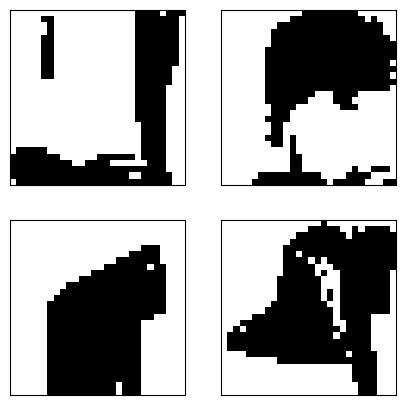

In [9]:
plt.figure(figsize=(5, 5))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(pixels[i]), cmap=plt.cm.binary)

### Ćwiczenia do wykonania
1. Uzupełnianie obrazu: Napisz fragment kodu, w którym przekazujesz modelowi zbiór obrazów testowych, ale wymazujesz dolną lub prawą połowę (ustawiasz wartości na 0). Wykorzystaj wyuczoną sieć PixelCNN do wygenerowania (uzupełnienia) brakującej reszty obrazu. Porównaj wynikowy wygenerowany obraz z oryginałem.
2. Zmodyfikuj aktualny kod tak aby próbował generować generować obrazy w skali szarości.
3. Generacja obrazów RGB: Przebuduj obecny model, aby przyjmował kolorowe obrazy (np. zbiór CIFAR-10) o wymiarach (32, 32, 3). Zastanów się i uzasadnij, dlaczego i jak należy upewnić się, że generowanie kolejnych kanałów kolorów (R, następnie G, następnie B) również przebiega w odpowiedniej maskowanej kolejności.

In [17]:
def complete_image(model, original_images, half="bottom"):
    batch, rows, cols, channels = original_images.shape
    masked_images = original_images.copy()

    # Wymazywanie połowy obrazu
    if half == "bottom":
        masked_images[:, rows // 2 :, :, :] = 0
    elif half == "right":
        masked_images[:, :, cols // 2 :, :] = 0

    completed_images = masked_images.copy()

    # Generowanie wymazanej części piksel po pikselu
    for row in range(rows):
        for col in range(cols):
            # Uzupełniamy tylko te piksele, które zostały wymazane
            if half == "bottom" and row < rows // 2:
                continue
            if half == "right" and col < cols // 2:
                continue

            for channel in range(channels):
                pix = model.predict(completed_images, verbose=0)[:, row, col, channel]
                completed_images[:, row, col, channel] = tf.math.ceil(
                    pix - tf.random.uniform(pix.shape)
                )

    return masked_images, completed_images

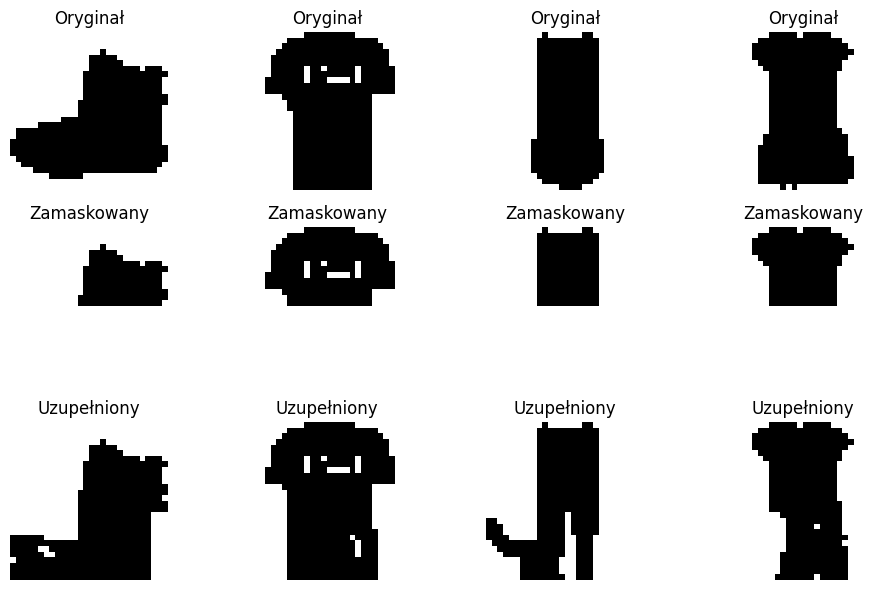

In [18]:
# Pobranie przykładowych 4 obrazków
sample_images = data[:4]
masked_images, completed_images = complete_image(
    pixel_cnn, sample_images, half="bottom"
)

plt.figure(figsize=(10, 6))
for i in range(4):
    plt.subplot(3, 4, i + 1)
    plt.imshow(np.squeeze(sample_images[i]), cmap=plt.cm.binary)
    plt.title("Oryginał")
    plt.axis("off")

    plt.subplot(3, 4, i + 5)
    plt.imshow(np.squeeze(masked_images[i]), cmap=plt.cm.binary)
    plt.title("Zamaskowany")
    plt.axis("off")

    plt.subplot(3, 4, i + 9)
    plt.imshow(np.squeeze(completed_images[i]), cmap=plt.cm.binary)
    plt.title("Uzupełniony")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [19]:
# Zamiast binarnej funkcji straty, należy użyć funkcji odzwierciedlającej
# wartości ciągłe [0, 1]. Dobrym wyborem jest błąd średniokwadratowy (MSE).

# 1. Przygotowanie danych w skali szarości (zamiast binarnych):
data_gray = tf.keras.datasets.fashion_mnist.load_data()[0][0]
data_gray = data_gray.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# 2. Definicja i kompilacja modelu:
# Architektura pozostaje podobna, wyjście wykorzystuje aktywację 'sigmoid'
# lub 'linear', aby dostarczyć wartości z zakresu [0, 1].

inputs = layers.Input(shape=(28, 28, 1))
x = PixelConvLayer(
    mask_type="A", filters=128, kernel_size=7, activation="relu", padding="same"
)(inputs)
for _ in range(5):
    x = ResidualBlock(filters=128)(x)
for _ in range(2):
    x = PixelConvLayer(
        mask_type="B",
        filters=128,
        kernel_size=1,
        strides=1,
        activation="relu",
        padding="valid",
    )(x)
out = layers.Conv2D(
    filters=1, kernel_size=1, strides=1, activation="sigmoid", padding="valid"
)(x)

pixel_cnn_gray = tf.keras.Model(inputs, out)
adam = tf.keras.optimizers.Adam(learning_rate=0.0005)
pixel_cnn_gray.compile(optimizer=adam, loss="mse")  # <--- Zmiana funkcji straty na MSE

# 3. Trening:
pixel_cnn_gray.fit(
    x=data_gray, y=data_gray, batch_size=128, epochs=15, validation_split=0.1
)

# 4. Generowanie obrazu (brak warunku losującego tf.math.ceil z szumem):
# Podczas predykcji nowej wartości piksela po prostu przyjmujemy przewidzianą
# wartość ciągłą z sieci.
pix = pixel_cnn_gray.predict(pixels, verbose=0)[:, row, col, channel]
pixels[:, row, col, channel] = pix

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 74s 123ms/step - loss: 0.0154 - val_loss: 0.0081
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 107ms/step - loss: 0.0077 - val_loss: 0.0073
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 103ms/step - loss: 0.0072 - val_loss: 0.0070
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - loss: 0.0068 - val_loss: 0.0067
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 104ms/step - loss: 0.0066 - val_loss: 0.0065
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 103ms/step - loss: 0.0065 - val_loss: 0.0063
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 104ms/step - loss: 0.0063 - val_loss: 0.0062
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 103ms/step - loss: 0.0062 - val_loss: 0.0061
Epoch 9/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 103ms/step - loss: 0.0061 - val_loss: 0.0061
Epoch 10/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 104ms/step - loss: 0.0061 - val_loss: 0.0060
Epoch 11/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 105ms/step - loss: 0.0060 - val_loss: 0.0059
Epoch 12/15
422/422

UZASADNIENIE DOTYCZĄCE MASKOWANIA:  
Dla wielokanałowych obrazów RGB (np. o kształcie 32x32x3) musimy zachować  
właściwość autogresywności również pomiędzy samymi kanałami dla tego samego piksela,  
ponieważ nie możemy ich traktować jako całkowicie niezależnych lub wygenerowanych w tym samym czasie.  
Zazwyczaj definiujemy to w kolejności: R, następnie G, następnie B.  
- Kanał R (czerwony) zależny jest od sąsiednich wygenerowanych PIKSELI z lewej/góry. Nie może patrzeć na G i B dla TEGO SAMEGO PIKSELA.
- Kanał G (zielony) zależy od sąsiednich pikseli ORAZ od kanału R dla TEGO SAMEGO PIKSELA.
- Kanał B (niebieski) zależy od sąsiednich pikseli ORAZ od kanałów R i G dla TEGO SAMEGO PIKSELA.

Dla zaawansowanych sieci typu PixelCNN z kolorami należy w mechanizmie 
maski jądra dodatkowo odrzucić/zezwolić na poszczególne mapowania między kanałami (tzw. channel masking) w pikselu centralnym.

In [27]:
class PixelConvLayerRGB(layers.Layer):
    """
    Szkic architektury maskowania dla warstwy RGB
    """

    def __init__(self, mask_type, filters, **kwargs):
        super().__init__()
        self.mask_type = mask_type
        # Zakładamy, że wymiar filtrów dzieli się przez 3, aby każda trójka odpowiadała RGB
        self.conv = layers.Conv2D(filters=filters, **kwargs)

    def build(self, input_shape):
        self.conv.build(input_shape)
        kernel_shape = self.conv.kernel.shape
        self.mask = np.zeros(shape=kernel_shape)

        # Tradycyjna maska przestrzenna 2D
        self.mask[: kernel_shape[0] // 2, ...] = 1.0
        self.mask[kernel_shape[0] // 2, : kernel_shape[1] // 2, ...] = 1.0

        if self.mask_type == "B":
            # Maskowanie wewnątrz kanałów w pikselu centralnym (np. wymiary in_channels, out_channels)
            # R widzi tylko R
            # G widzi R i G
            # B widzi R, G i B
            pass

    def call(self, inputs):
        self.conv.kernel.assign(self.conv.kernel * self.mask)
        return self.conv(inputs)


# Przebudowany model przyjmujący obraz 32x32x3
input_rgb = layers.Input(shape=(32, 32, 3))
# Ostatnia warstwa również musiałaby generować 3 filtry (1 filtr na kanał)
out_rgb = layers.Conv2D(
    filters=3, kernel_size=1, strides=1, activation="sigmoid", padding="valid"
)(input_rgb)

## Model GAN

Przygotowanie danych

In [6]:
(train_images, train_labels) = tf.keras.datasets.fashion_mnist.load_data()[0]

# Dodanie wymiaru kanału (28, 28) -> (28, 28, 1) i rzutowanie na float32
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype("float32")

# Normalizacja do zakresu [0, 1] (zgodnie z aktywacją 'sigmoid' w generatorze)
train_images = train_images / 255.0

# Parametry uczenia
BUFFER_SIZE = 60000
BATCH_SIZE = 256
LATENT_DIM = 100
EPOCHS = 50

# Tworzenie potoku danych (Dataset) do optymalnego ładowania paczek (batches)
train_dataset = (
    tf.data.Dataset.from_tensor_slices(train_images)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
)

I0000 00:00:1777319435.486251  579583 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4078 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5
2026-04-27 21:50:35.492020: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.
2026-04-27 21:50:35.847350: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.


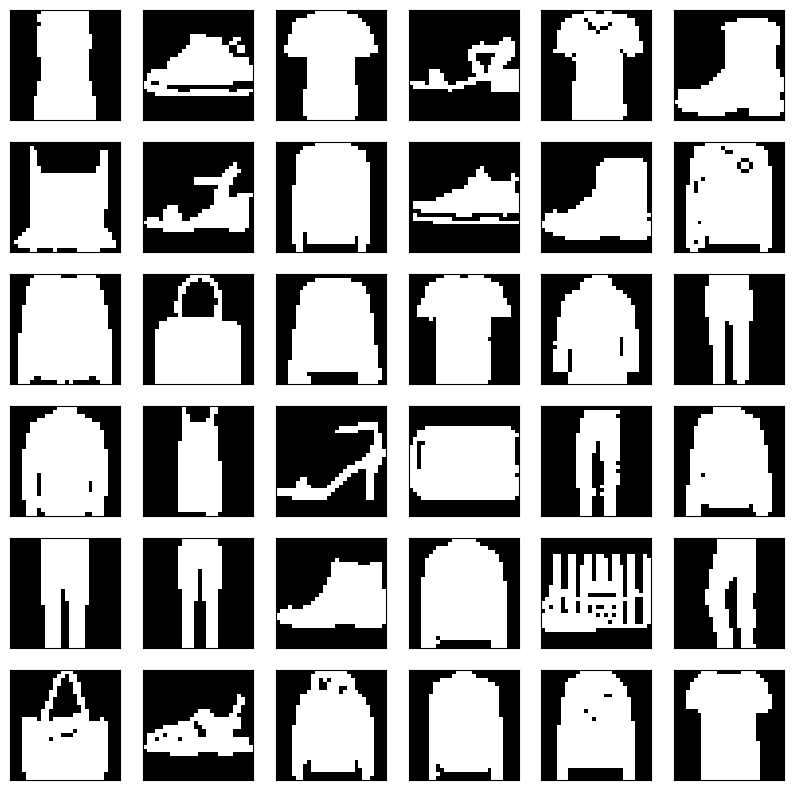

In [11]:
plt.figure(figsize=(10, 10))
random_inds = np.random.choice(60000, 36)
for i in range(36):
    plt.subplot(6, 6, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    image_ind = random_inds[i]
    plt.imshow(np.squeeze(data[image_ind]), cmap="gray")

Budowa składowych modelu

In [12]:
def build_discriminator(input_shape=(28, 28, 1)):
    """
    Dyskryminator: ocenia czy obraz jest prawdziwy (z danych) czy fałszywy (wygenerowany).
    """
    model = tf.keras.Sequential(name="Discriminator")
    model.add(layers.InputLayer(shape=input_shape))
    model.add(layers.Conv2D(64, kernel_size=3, strides=2, padding="same"))
    model.add(
        layers.LeakyReLU(negative_slope=0.2)
    )  # LeakyReLU jest stabilniejsze w dyskryminatorach

    model.add(layers.Conv2D(128, kernel_size=3, strides=2, padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(negative_slope=0.2))

    model.add(layers.Flatten())
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation="sigmoid"))  # Wyjście: 0 = fałsz, 1 = prawda
    return model


def build_generator(latent_dim=100):
    """
    Generator: tworzy nowe obrazy na podstawie losowego wektora szumu (latent_dim).
    """
    model = tf.keras.Sequential(name="Generator")
    model.add(layers.InputLayer(shape=(latent_dim,)))
    # Przekształcamy płaski wektor w głęboki i mały tensor 7x7
    model.add(layers.Dense(7 * 7 * 128, activation="relu"))
    model.add(layers.Reshape((7, 7, 128)))

    model.add(
        layers.Conv2DTranspose(
            64, kernel_size=3, strides=2, padding="same", activation="relu"
        )
    )
    model.add(layers.BatchNormalization())

    # Ostatnia warstwa dekodująca do wymiarów 28x28x1
    model.add(
        layers.Conv2DTranspose(
            1, kernel_size=3, strides=2, padding="same", activation="sigmoid"
        )
    )
    return model

In [13]:
generator = build_generator(LATENT_DIM)
discriminator = build_discriminator()

Funkcja kroku uczenia

In [9]:
loss_fn = tf.keras.losses.BinaryCrossentropy()

# Parametry beta_1=0.5 są standardem stabilizującym uczenie GANów w optymalizatorze Adam
gen_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
disc_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)


@tf.function
def train_step(real_images):
    batch_size = tf.shape(real_images)[0]
    random_noise = tf.random.normal([batch_size, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generowanie fałszywych obrazów
        fake_images = generator(random_noise, training=True)

        # Oceny dyskryminatora
        real_predictions = discriminator(real_images, training=True)
        fake_predictions = discriminator(fake_images, training=True)

        # STRATY DYSKRYMINATORA:
        # prawdziwe obrazy powinny być blisko 1, fałszywe blisko 0
        disc_loss_real = loss_fn(tf.ones_like(real_predictions), real_predictions)
        disc_loss_fake = loss_fn(tf.zeros_like(fake_predictions), fake_predictions)
        disc_loss = disc_loss_real + disc_loss_fake

        # STRATY GENERATORA:
        # generator chce, aby jego fałszywe obrazy zostały ocenione jako 1 (prawda)
        gen_loss = loss_fn(tf.ones_like(fake_predictions), fake_predictions)

    # Obliczanie gradientów
    gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # Aktualizacja wag
    gen_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
    disc_optimizer.apply_gradients(
        zip(disc_gradients, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss

Główna pętla ucząca wraz z wizualizacją

In [15]:
# Stały wektor szumu pozwala obserwować ewolucję tych samych "obrazów" z epoki na epokę
seed = tf.random.normal([16, LATENT_DIM])


def generate_and_save_images(model, epoch, test_input):
    # Wywołanie generatora w trybie testowym (training=False), np. dla warstw BatchNormalization
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        # Odwracamy normalizację dla wyświetlania (wymiar 28x28)
        plt.imshow(predictions[i, :, :, 0] * 255.0, cmap="gray")
        plt.axis("off")

    plt.suptitle(f"Epoka: {epoch}")
    plt.show()


def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()

        # Inicjalizacja zmiennych do śledzenia średniej straty w epoce
        total_gen_loss = 0
        total_disc_loss = 0
        batches = 0

        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)
            total_gen_loss += gen_loss
            total_disc_loss += disc_loss
            batches += 1

        # Wizualizacja postępu
        display.clear_output(wait=True)
        generate_and_save_images(generator, epoch + 1, seed)

        print(f"Czas dla epoki {epoch + 1} wynosi {time.time()-start:.2f} sek.")
        print(
            f"Strata Gen: {total_gen_loss/batches:.4f} | Strata Disc: {total_disc_loss/batches:.4f}"
        )

    # Wyświetlenie końcowego obrazu
    display.clear_output(wait=True)
    generate_and_save_images(generator, epochs, seed)

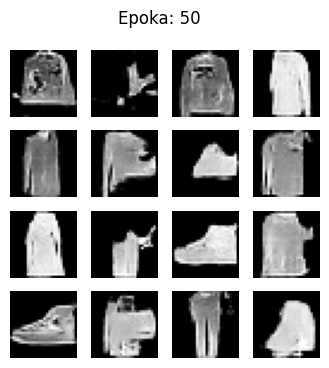

In [16]:
train(train_dataset, EPOCHS)

### Ćwiczenia do wykonania
1. Zapaść trybu: Wytrenuj model GAN przez znacznie większą liczbę epok. Po pewnym czasie wygeneruj grid ze 100 obrazkami. Zbadaj, czy model zaczyna produkować powtarzające się i nieodróżnialne od siebie grafiki, tracąc różnorodność. Zastosuj technikę „label smoothing” (np. przypisanie obrazom prawdziwym etykiety 0.9 zamiast 1.0) i sprawdź, czy rozwiązuje to problem.
2. Interpolacja w przestrzeni ukrytej: Napisz funkcję, która wylosuje dwa różne wektory szumu ($z_1$ oraz $z_2$). Wykonaj pomiędzy nimi interpolację liniową (np. wygeneruj 10 kroków pośrednich) i podaj je do generatora. Przedstaw wygenerowane obrazy jeden obok drugiego i zaobserwuj, w jaki sposób jeden element garderoby płynnie przekształca się w drugi.
3. Conditional GAN (cGAN): Dostosuj Generator i Dyskryminator, aby poza obrazem otrzymywały również jako wejście „etykietę ubrania” (w formie wektora one-hot z modyfikacją warstwy osadzeń - Embedding). Wykorzystaj tę metodę do nakazania generatorowi utworzenia konkretnego, wybranego przez Ciebie obiektu z Fashion MNIST (np. "tylko buty" lub "tylko torebki").


In [28]:
@tf.function
def train_step_smoothed(real_images):
    batch_size = tf.shape(real_images)[0]
    random_noise = tf.random.normal([batch_size, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(random_noise, training=True)

        real_predictions = discriminator(real_images, training=True)
        fake_predictions = discriminator(fake_images, training=True)

        # Label smoothing dla prawdziwych obrazów: cel 0.9 zamiast 1.0
        disc_loss_real = loss_fn(
            tf.fill(tf.shape(real_predictions), 0.9), real_predictions
        )
        disc_loss_fake = loss_fn(tf.zeros_like(fake_predictions), fake_predictions)
        disc_loss = disc_loss_real + disc_loss_fake

        gen_loss = loss_fn(tf.ones_like(fake_predictions), fake_predictions)

    gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
    disc_optimizer.apply_gradients(
        zip(disc_gradients, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss


def train_smoothed(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            train_step_smoothed(image_batch)
        print(f"Epoch {epoch+1} finished")


# Ponowna inicjalizacja modeli
generator = build_generator(LATENT_DIM)
discriminator = build_discriminator()
gen_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
disc_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

train_smoothed(train_dataset, 100)

Epoch 1 finished
Epoch 2 finished
Epoch 3 finished
Epoch 4 finished
Epoch 5 finished
Epoch 6 finished
Epoch 7 finished
Epoch 8 finished
Epoch 9 finished
Epoch 10 finished
Epoch 11 finished
Epoch 12 finished
Epoch 13 finished


2026-04-27 21:28:48.682715: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 14 finished
Epoch 15 finished
Epoch 16 finished
Epoch 17 finished
Epoch 18 finished
Epoch 19 finished
Epoch 20 finished
Epoch 21 finished
Epoch 22 finished
Epoch 23 finished
Epoch 24 finished
Epoch 25 finished
Epoch 26 finished
Epoch 27 finished
Epoch 28 finished
Epoch 29 finished
Epoch 30 finished
Epoch 31 finished
Epoch 32 finished
Epoch 33 finished
Epoch 34 finished
Epoch 35 finished
Epoch 36 finished
Epoch 37 finished
Epoch 38 finished
Epoch 39 finished
Epoch 40 finished
Epoch 41 finished
Epoch 42 finished
Epoch 43 finished
Epoch 44 finished
Epoch 45 finished
Epoch 46 finished
Epoch 47 finished
Epoch 48 finished
Epoch 49 finished
Epoch 50 finished
Epoch 51 finished
Epoch 52 finished
Epoch 53 finished
Epoch 54 finished
Epoch 55 finished
Epoch 56 finished
Epoch 57 finished
Epoch 58 finished
Epoch 59 finished
Epoch 60 finished
Epoch 61 finished
Epoch 62 finished
Epoch 63 finished
Epoch 64 finished
Epoch 65 finished
Epoch 66 finished
Epoch 67 finished
Epoch 68 finished
Epoch 69 f

2026-04-27 21:36:01.515460: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 78 finished
Epoch 79 finished
Epoch 80 finished
Epoch 81 finished
Epoch 82 finished
Epoch 83 finished
Epoch 84 finished
Epoch 85 finished
Epoch 86 finished
Epoch 87 finished
Epoch 88 finished
Epoch 89 finished
Epoch 90 finished
Epoch 91 finished
Epoch 92 finished
Epoch 93 finished
Epoch 94 finished
Epoch 95 finished
Epoch 96 finished
Epoch 97 finished
Epoch 98 finished
Epoch 99 finished
Epoch 100 finished


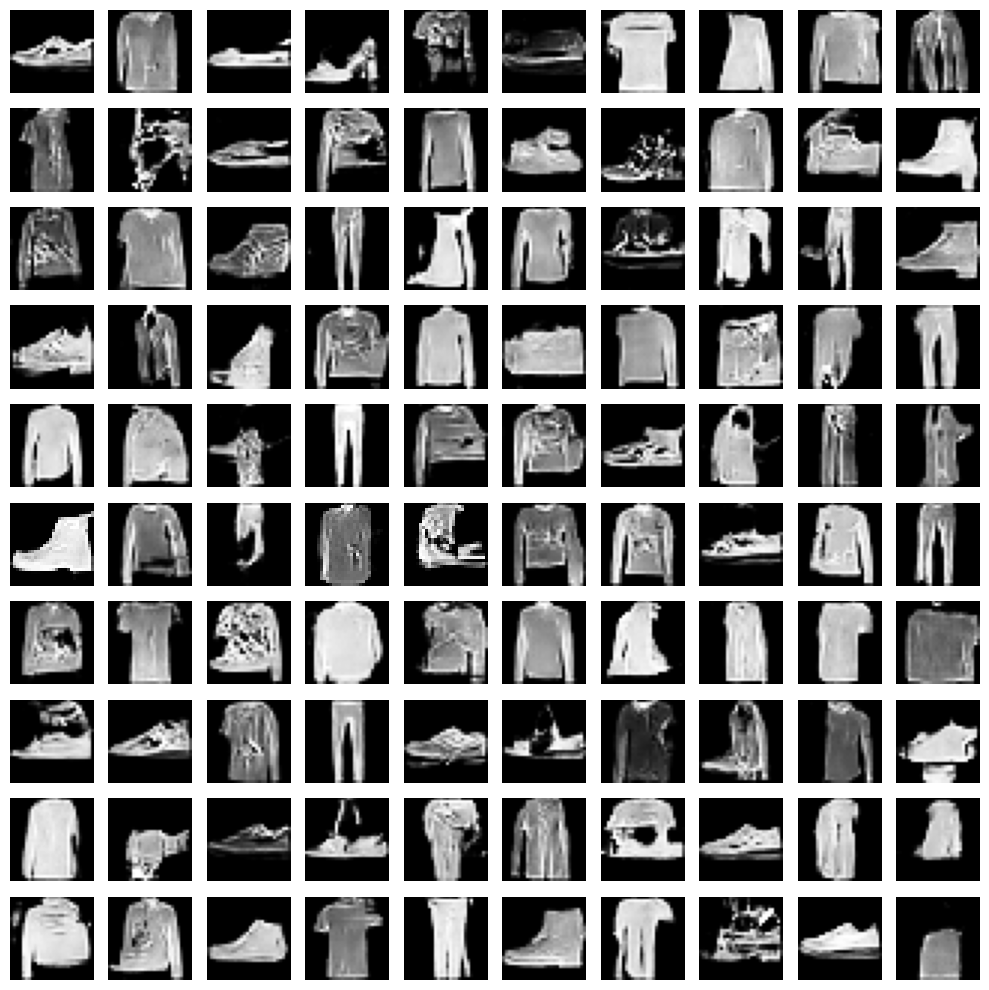

In [29]:
# Wygenerowanie 100 obrazków
def plot_100_images(model):
    noise = tf.random.normal([100, LATENT_DIM])
    generated_images = model(noise, training=False)

    fig = plt.figure(figsize=(10, 10))
    for i in range(100):
        plt.subplot(10, 10, i + 1)
        plt.imshow(generated_images[i, :, :, 0] * 255.0, cmap="gray")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


plot_100_images(generator)

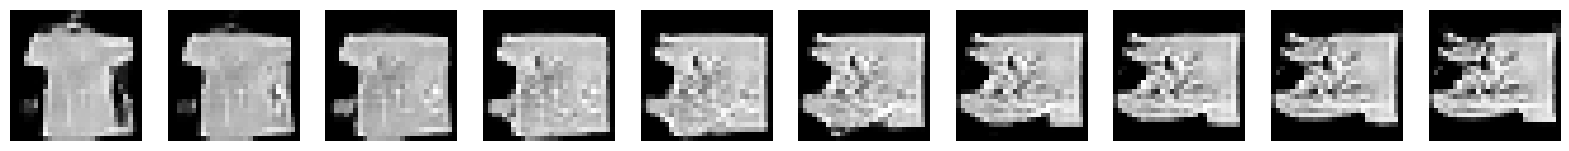

In [ ]:
def interpolate_points(p1, p2, n_steps=10):
    ratios = np.linspace(0, 1, num=n_steps)
    vectors = list()
    for ratio in ratios:
        v = (1.0 - ratio) * p1 + ratio * p2
        vectors.append(v)
    return np.asarray(vectors)


def generate_interpolated_images(model, z1, z2, n_steps=10):
    interpolated_z = interpolate_points(z1, z2, n_steps)
    # Zmiana kształtu na (n_steps, LATENT_DIM)
    interpolated_z = tf.reshape(interpolated_z, (n_steps, LATENT_DIM))

    generated_images = model(interpolated_z, training=False)

    plt.figure(figsize=(n_steps * 2, 2))
    for i in range(n_steps):
        plt.subplot(1, n_steps, i + 1)
        plt.imshow(generated_images[i, :, :, 0] * 255.0, cmap="gray")
        plt.axis("off")
    plt.show()


# Losowe wektory szumu
z1 = tf.random.normal([1, LATENT_DIM])
z2 = tf.random.normal([1, LATENT_DIM])

# Uruchomienie generowania interpolacji
generate_interpolated_images(generator, z1, z2, n_steps=10)

In [ ]:
num_classes = 10


def build_cgan_generator(latent_dim=100, num_classes=10):
    # Wejście dla wektora szumu
    noise_input = layers.Input(shape=(latent_dim,))
    # Wjście dla etykiety klasy
    label_input = layers.Input(shape=(1,))

    # Warstwa Embedding dla etykiety
    label_embedding = layers.Embedding(num_classes, 50)(label_input)
    label_embedding = layers.Flatten()(label_embedding)

    # Połączenie szumu i etykiety
    merged = layers.Concatenate()([noise_input, label_embedding])

    x = layers.Dense(7 * 7 * 128, activation="relu")(merged)
    x = layers.Reshape((7, 7, 128))(x)

    x = layers.Conv2DTranspose(
        64, kernel_size=3, strides=2, padding="same", activation="relu"
    )(x)
    x = layers.BatchNormalization()(x)

    out_image = layers.Conv2DTranspose(
        1, kernel_size=3, strides=2, padding="same", activation="sigmoid"
    )(x)

    return tf.keras.Model([noise_input, label_input], out_image, name="cGAN_Generator")


def build_cgan_discriminator(input_shape=(28, 28, 1), num_classes=10):
    # Wejście dla obrazu (prawdziwego lub fałszywego)
    image_input = layers.Input(shape=input_shape)
    # Wejście dla etykiety
    label_input = layers.Input(shape=(1,))

    # Embedding etykiety przeskalowany przestrzennie do rozmiaru obrazu
    label_embedding = layers.Embedding(num_classes, 50)(label_input)
    label_embedding = layers.Dense(input_shape[0] * input_shape[1])(label_embedding)
    label_embedding = layers.Reshape((input_shape[0], input_shape[1], 1))(
        label_embedding
    )

    # Konkatenacja obrazu i osadzonej etykiety na poziomie kanałów
    merged = layers.Concatenate()([image_input, label_embedding])

    x = layers.Conv2D(64, kernel_size=3, strides=2, padding="same")(merged)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv2D(128, kernel_size=3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    return tf.keras.Model([image_input, label_input], out, name="cGAN_Discriminator")


# Inicjalizacja modeli cGAN
cgan_generator = build_cgan_generator(LATENT_DIM, num_classes)
cgan_discriminator = build_cgan_discriminator(
    input_shape=(28, 28, 1), num_classes=num_classes
)

cgan_generator.summary()
cgan_discriminator.summary()

Model: "cGAN_Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │        500 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 150)       │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 6272)      │    947,072 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 7, 7, 128) │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 14, 14,    │     73,792 │ reshape[0][0]     │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 14, 14,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 28, 28, 1) │        577 │ batch_normalizat… │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,022,197 (3.90 MB)

 Trainable params: 1,022,069 (3.90 MB)

 Non-trainable params: 128 (512.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 50)     │        500 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 784)    │     39,984 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 28, 28, 1) │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 28, 28, 2) │          0 │ input_layer_2[0]… │
│ (Concatenate)       │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │      1,216 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 14, 14,    │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 128) │     73,856 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 128) │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 7, 7, 128) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 6272)      │          0 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 6272)      │          0 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │      6,273 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 122,341 (477.89 KB)

 Trainable params: 122,085 (476.89 KB)

 Non-trainable params: 256 (1.00 KB)

2026-04-27 21:50:49.035047: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


2026-04-27 21:51:41.612161: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoka 1/30 | Gen Loss: 2.6238 | Disc Loss: 0.2634


2026-04-27 21:51:55.385842: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoka 2/30 | Gen Loss: 2.0145 | Disc Loss: 0.5695
Epoka 3/30 | Gen Loss: 1.6431 | Disc Loss: 0.6811


2026-04-27 21:52:20.439981: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoka 4/30 | Gen Loss: 1.5593 | Disc Loss: 0.7457
Epoka 5/30 | Gen Loss: 1.5429 | Disc Loss: 0.7678
Epoka 6/30 | Gen Loss: 1.5879 | Disc Loss: 0.7496
Epoka 7/30 | Gen Loss: 1.6096 | Disc Loss: 0.7651


2026-04-27 21:53:06.101387: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoka 8/30 | Gen Loss: 1.4664 | Disc Loss: 0.8702
Epoka 9/30 | Gen Loss: 1.3782 | Disc Loss: 0.9477
Epoka 10/30 | Gen Loss: 1.3636 | Disc Loss: 0.9578
Epoka 11/30 | Gen Loss: 1.3062 | Disc Loss: 1.0140
Epoka 12/30 | Gen Loss: 1.2226 | Disc Loss: 1.0832
Epoka 13/30 | Gen Loss: 1.2410 | Disc Loss: 1.0576
Epoka 14/30 | Gen Loss: 1.1882 | Disc Loss: 1.1167
Epoka 15/30 | Gen Loss: 1.1658 | Disc Loss: 1.1234


2026-04-27 21:54:29.748465: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoka 16/30 | Gen Loss: 1.1844 | Disc Loss: 1.0857
Epoka 17/30 | Gen Loss: 1.1614 | Disc Loss: 1.1385
Epoka 18/30 | Gen Loss: 1.1401 | Disc Loss: 1.1262
Epoka 19/30 | Gen Loss: 1.1317 | Disc Loss: 1.1439
Epoka 20/30 | Gen Loss: 1.1203 | Disc Loss: 1.1547
Epoka 21/30 | Gen Loss: 1.0798 | Disc Loss: 1.1795
Epoka 22/30 | Gen Loss: 1.0650 | Disc Loss: 1.1808
Epoka 23/30 | Gen Loss: 1.0476 | Disc Loss: 1.1923
Epoka 24/30 | Gen Loss: 1.0299 | Disc Loss: 1.2025
Epoka 25/30 | Gen Loss: 1.0284 | Disc Loss: 1.1870
Epoka 26/30 | Gen Loss: 1.0495 | Disc Loss: 1.1787
Epoka 27/30 | Gen Loss: 1.0357 | Disc Loss: 1.1792
Epoka 28/30 | Gen Loss: 1.0456 | Disc Loss: 1.1835
Epoka 29/30 | Gen Loss: 1.0009 | Disc Loss: 1.2098
Epoka 30/30 | Gen Loss: 1.0175 | Disc Loss: 1.1986


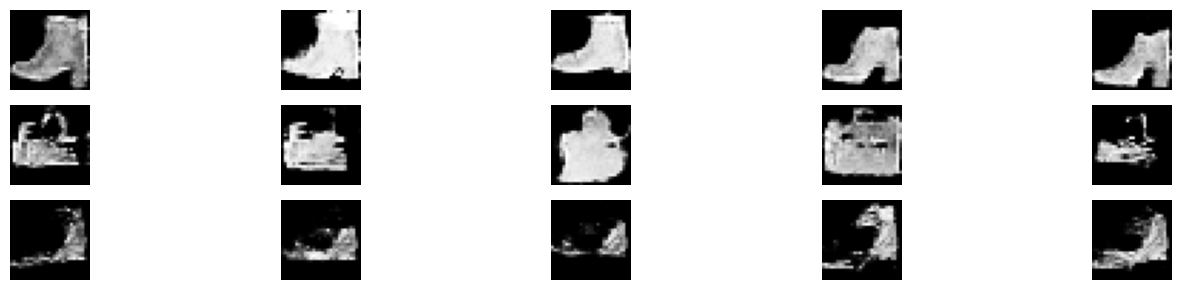

In [10]:
cgan_gen_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
cgan_disc_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)


@tf.function
def train_step_cgan(real_images, real_labels):
    batch_size = tf.shape(real_images)[0]
    random_noise = tf.random.normal([batch_size, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = cgan_generator([random_noise, real_labels], training=True)

        real_predictions = cgan_discriminator([real_images, real_labels], training=True)
        fake_predictions = cgan_discriminator([fake_images, real_labels], training=True)

        disc_loss_real = loss_fn(tf.ones_like(real_predictions), real_predictions)
        disc_loss_fake = loss_fn(tf.zeros_like(fake_predictions), fake_predictions)
        disc_loss = disc_loss_real + disc_loss_fake

        gen_loss = loss_fn(tf.ones_like(fake_predictions), fake_predictions)

    gen_gradients = gen_tape.gradient(gen_loss, cgan_generator.trainable_variables)
    disc_gradients = disc_tape.gradient(
        disc_loss, cgan_discriminator.trainable_variables
    )

    cgan_gen_optimizer.apply_gradients(
        zip(gen_gradients, cgan_generator.trainable_variables)
    )
    cgan_disc_optimizer.apply_gradients(
        zip(disc_gradients, cgan_discriminator.trainable_variables)
    )

    return gen_loss, disc_loss


def train_cgan(epochs=30):
    for epoch in range(epochs):
        total_gen_loss = 0
        total_disc_loss = 0
        batches = 0

        for image_batch, label_batch in tf.data.Dataset.from_tensor_slices(
            (train_images, train_labels)
        ).batch(BATCH_SIZE):
            label_batch = tf.reshape(label_batch, (-1, 1))
            gen_loss, disc_loss = train_step_cgan(image_batch, label_batch)
            total_gen_loss += gen_loss
            total_disc_loss += disc_loss
            batches += 1

        print(
            f"Epoka {epoch + 1}/{epochs} | Gen Loss: {total_gen_loss/batches:.4f} | Disc Loss: {total_disc_loss/batches:.4f}"
        )


train_cgan(epochs=30)


def generate_class_samples(model, class_labels, num_samples=10):
    fig = plt.figure(figsize=(15, 3))
    for idx, class_label in enumerate(class_labels):
        noise = tf.random.normal([num_samples, LATENT_DIM])
        labels = tf.fill([num_samples, 1], class_label)
        generated = model([noise, labels], training=False)

        for i in range(num_samples):
            plt.subplot(len(class_labels), num_samples, idx * num_samples + i + 1)
            plt.imshow(generated[i, :, :, 0] * 255.0, cmap="gray")
            plt.axis("off")

    plt.tight_layout()
    plt.show()


generate_class_samples(cgan_generator, class_labels=[9, 8, 5], num_samples=5)